## An analysis on the spatial gridpoint of WeatherBench data

Analysing the gridpoints
- Motivation: Spherical geometry motivates the use of kernels on sphere
    - What is the difference in distance value for geodesic distance and euclidean distance? For points closer to each other, we expect there isn't much difference between the two. In this case, does a kernel that focuses on short-range correlation does not matter if it is designed on a sphere or not? Intuitively, kernels on a sphere performs better on capturing long-range correlations since this is where the difference between the geodesic distance and euclidean distance differs the most. How can we test this? (We've shown with geometric_kernel, there is not significant difference in terms of the rmse)
- Motivation: What are the appropriate lengthscales for our spatial kernels? What is considered a short-ranged, a medium-ranged and a long-ranged distance on this grid?

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

from GPyTorch.utils import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
z500 = xr.open_mfdataset('data/5.625deg/geopotential_500/*.nc', combine='by_coords')

In [5]:
lat = z500.lat.values
lon = z500.lon.values
(lat.shape[0], lon.shape[0])

(32, 64)

In [6]:
lat, lon

(array([-87.1875, -81.5625, -75.9375, -70.3125, -64.6875, -59.0625,
        -53.4375, -47.8125, -42.1875, -36.5625, -30.9375, -25.3125,
        -19.6875, -14.0625,  -8.4375,  -2.8125,   2.8125,   8.4375,
         14.0625,  19.6875,  25.3125,  30.9375,  36.5625,  42.1875,
         47.8125,  53.4375,  59.0625,  64.6875,  70.3125,  75.9375,
         81.5625,  87.1875]),
 array([  0.   ,   5.625,  11.25 ,  16.875,  22.5  ,  28.125,  33.75 ,
         39.375,  45.   ,  50.625,  56.25 ,  61.875,  67.5  ,  73.125,
         78.75 ,  84.375,  90.   ,  95.625, 101.25 , 106.875, 112.5  ,
        118.125, 123.75 , 129.375, 135.   , 140.625, 146.25 , 151.875,
        157.5  , 163.125, 168.75 , 174.375, 180.   , 185.625, 191.25 ,
        196.875, 202.5  , 208.125, 213.75 , 219.375, 225.   , 230.625,
        236.25 , 241.875, 247.5  , 253.125, 258.75 , 264.375, 270.   ,
        275.625, 281.25 , 286.875, 292.5  , 298.125, 303.75 , 309.375,
        315.   , 320.625, 326.25 , 331.875, 337.5  , 343.125, 

In [7]:
# Split into 16 blocks
blocks = {}
for i in range(4):  # 4 blocks along lat (32/8 = 4)
    for j in range(4):  # 4 blocks along lon (64/16 = 4)
        key = f"block_{i}_{j}"
        blocks[key] = z500.isel(
            lat=slice(i * 8, (i + 1) * 8),
            lon=slice(j * 16, (j + 1) * 16)
        )

coords = []
for k, v in blocks.items():
    print(f"{k}: {v.z.shape}")
    coords.append([v.lat.values, v.lon.values])

block_0_0: (350640, 8, 16)
block_0_1: (350640, 8, 16)
block_0_2: (350640, 8, 16)
block_0_3: (350640, 8, 16)
block_1_0: (350640, 8, 16)
block_1_1: (350640, 8, 16)
block_1_2: (350640, 8, 16)
block_1_3: (350640, 8, 16)
block_2_0: (350640, 8, 16)
block_2_1: (350640, 8, 16)
block_2_2: (350640, 8, 16)
block_2_3: (350640, 8, 16)
block_3_0: (350640, 8, 16)
block_3_1: (350640, 8, 16)
block_3_2: (350640, 8, 16)
block_3_3: (350640, 8, 16)


Converting to cartesian coordinates and then visualising the gridpoints (lat: -90 to 90 / lon: 0 to 360)

In [8]:
xyz = latlon_to_cartesian(lat, lon)
xyz.shape

(32, 64, 3)

In [47]:
coords_to_xyz = []
for x in coords:
    xyz_coords = latlon_to_cartesian(x[0], x[1])
    coords_to_xyz.append(xyz_coords.reshape(-1,3))

In [44]:
# subsampled grid
subsample = 5
sub_xyz = xyz[::subsample,::subsample,:].reshape(-1,3)
sub_xyz.shape

(91, 3)

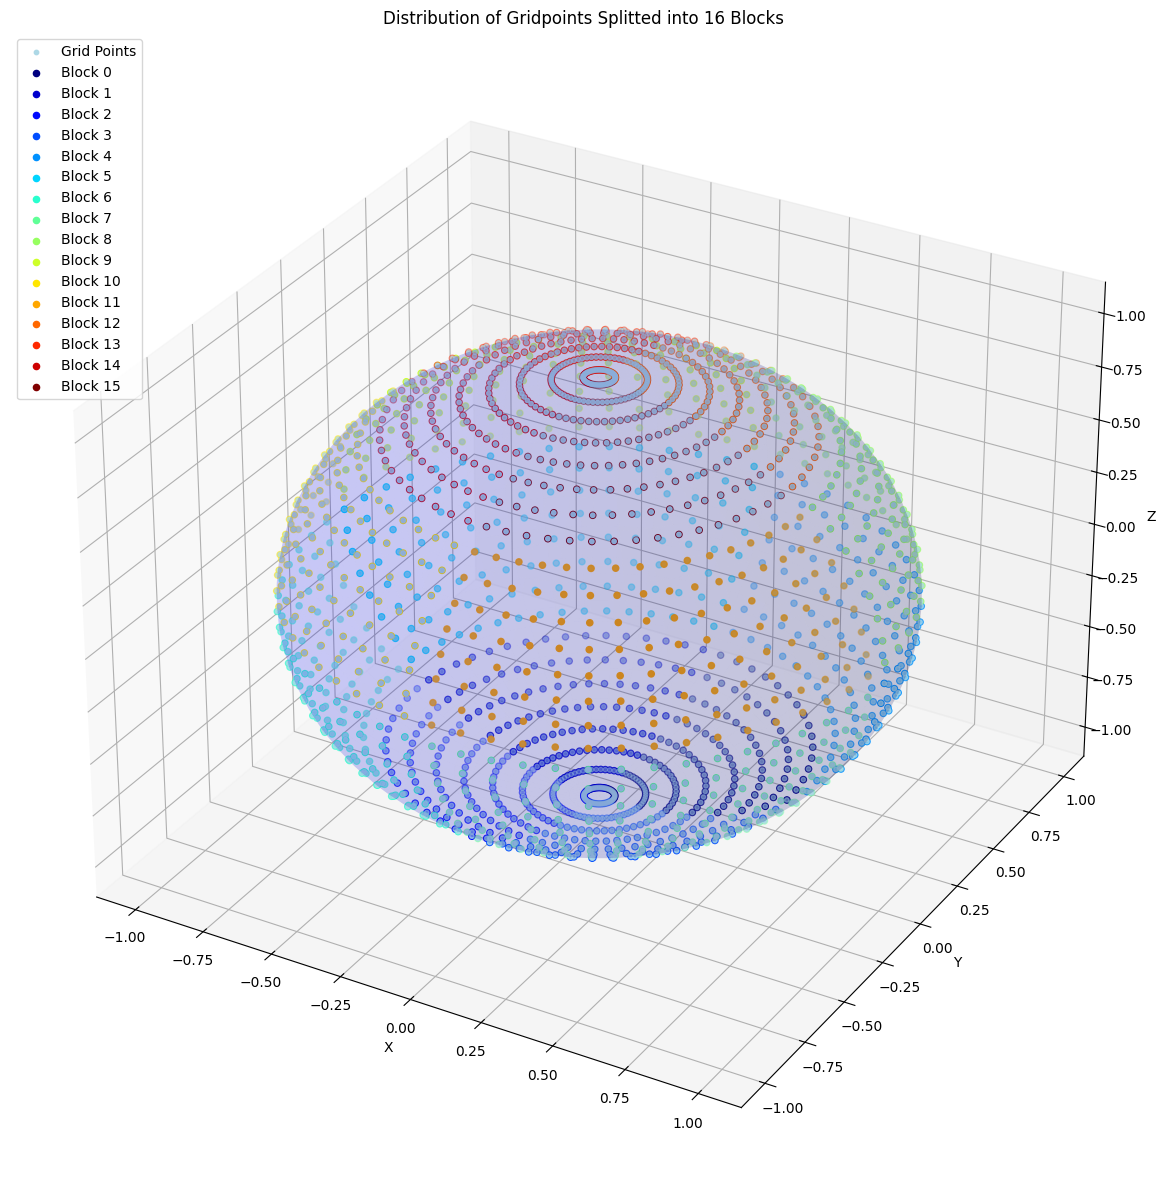

In [55]:
from mpl_toolkits.mplot3d import Axes3D 

colors = plt.cm.jet(np.linspace(0, 1, len(coords_to_xyz)))

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(xyz.reshape(-1,3)[:,0], xyz.reshape(-1,3)[:,1], xyz.reshape(-1,3)[:,2], color='lightblue', s=10, label='Grid Points')
for i, x in enumerate(coords_to_xyz):
    ax.scatter(x[:,0], x[:,1], x[:,2], color=colors[i], s=20, label=f'Block {i}')

#ax.scatter(sub_xyz.reshape(-1,3)[:,0], sub_xyz.reshape(-1,3)[:,1], sub_xyz.reshape(-1,3)[:,2], color='darkblue', s=20, label=rf'Sub-sampled Grid - Every {subsample}th Point')

# Optionally, add a semi-transparent sphere for reference
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(xs, ys, zs, color='b', alpha=0.1, edgecolor='none')

# Set plot attributes
ax.set_title('Distribution of Gridpoints Splitted into 16 Blocks')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

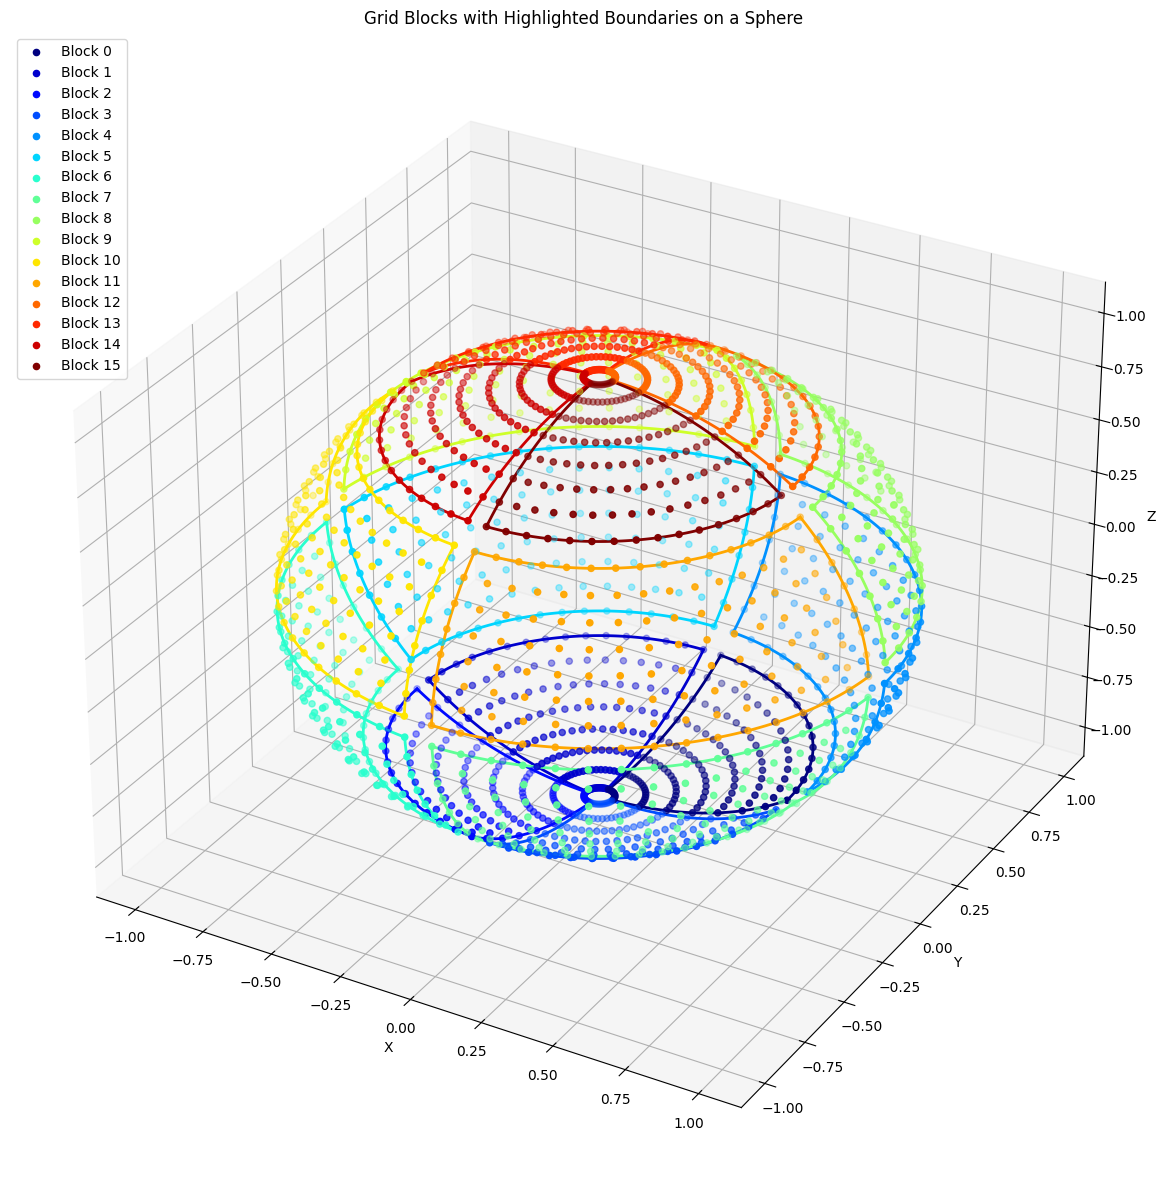

In [ ]:
# Element-wise conversion (for boundary lines)
def latlon_to_cartesian_point(lat, lon):
    """
    Convert arrays of lat and lon (of the same shape) element-wise into Cartesian coordinates.
    Returns an array of shape (N, 3).
    """
    lat_rad = np.deg2rad(lat)
    lon_rad = np.deg2rad(lon)
    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)
    return np.stack([x, y, z], axis=-1)

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

num_blocks = len(coords)
colors = plt.cm.jet(np.linspace(0, 1, num_blocks))
# Plot each block's points and draw the boundary box
for i, (lat_block, lon_block) in enumerate(coords):
    # Convert the block's grid points to Cartesian coordinates (8 x 16 grid)
    block_xyz = latlon_to_cartesian(lat_block, lon_block).reshape(-1, 3)
    ax.scatter(block_xyz[:, 0], block_xyz[:, 1], block_xyz[:, 2],
               color=colors[i], s=20, label=f"Block {i}")

    # Determine the boundary values for the block
    lat_min, lat_max = lat_block.min(), lat_block.max()
    lon_min, lon_max = lon_block.min(), lon_block.max()

    # Number of points to sample along each edge
    num_samples = 100

    # Lower edge (constant latitude at lat_min, longitude varies)
    lons_edge = np.linspace(lon_min, lon_max, num_samples)
    lats_edge = np.full_like(lons_edge, lat_min)
    lower_edge_xyz = latlon_to_cartesian_point(lats_edge, lons_edge)

    # Upper edge (constant latitude at lat_max, longitude varies)
    lons_edge = np.linspace(lon_min, lon_max, num_samples)
    lats_edge = np.full_like(lons_edge, lat_max)
    upper_edge_xyz = latlon_to_cartesian_point(lats_edge, lons_edge)

    # Left edge (constant longitude at lon_min, latitude varies)
    lats_edge = np.linspace(lat_min, lat_max, num_samples)
    lons_edge = np.full_like(lats_edge, lon_min)
    left_edge_xyz = latlon_to_cartesian_point(lats_edge, lons_edge)

    # Right edge (constant longitude at lon_max, latitude varies)
    lats_edge = np.linspace(lat_min, lat_max, num_samples)
    lons_edge = np.full_like(lats_edge, lon_max)
    right_edge_xyz = latlon_to_cartesian_point(lats_edge, lons_edge)

    # Plot the boundary lines
    ax.plot(lower_edge_xyz[:, 0], lower_edge_xyz[:, 1], lower_edge_xyz[:, 2],
            color=colors[i], linewidth=2)
    ax.plot(upper_edge_xyz[:, 0], upper_edge_xyz[:, 1], upper_edge_xyz[:, 2],
            color=colors[i], linewidth=2)
    ax.plot(left_edge_xyz[:, 0], left_edge_xyz[:, 1], left_edge_xyz[:, 2],
            color=colors[i], linewidth=2)
    ax.plot(right_edge_xyz[:, 0], right_edge_xyz[:, 1], right_edge_xyz[:, 2],
            color=colors[i], linewidth=2)

ax.set_title("Grid Blocks with Highlighted Boundaries on a Sphere")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Average distance between neighbouring points on a normalised sphere

We use the haversine distance. The haversine distance (great circle distance) is the angular distance between two points on the surface of a sphere.

$$D(x,y) = 2 \text{arcsin} \left[ \sqrt{\sin^2((x_{\text{lat}}-y_{\text{lat}})/2)) + \cos(x_{\text{lat}})\cos(y_{\text{lat}})\sin^2((x_{\text{lon}}-y_{\text{lon}})/2))}\right]$$

From Scikit-learn documentation: As the Earth is nearly spherical, the haversine formula provides a good approximation of the distance between two points of the Earth surface, with a less than 1% error on average.

In [8]:
def haversine_distance(lat1, lon1, lat2, lon2, radius=1):
    # Radius of earth = 6371 km

    # Convert degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return radius * c

In [9]:
lat_grid, lon_grid = np.meshgrid(lat, lon, indexing='ij')

In [10]:
def average_neighbor_distance(lat_grid, lon_grid, radius=1):
    # Compute right neighbor distances with wrap-around (longitude)
    lat_right = np.roll(lat_grid, -1, axis=1)
    lon_right = np.roll(lon_grid, -1, axis=1)
    dist_right = haversine_distance(lat_grid, lon_grid, lat_right, lon_right, radius)
    
    # Compute downward neighbor distances using slicing (no wrap-around in latitude)
    lat_down = lat_grid[:-1, :]
    lon_down = lon_grid[:-1, :]
    lat_down_neighbor = lat_grid[1:, :]
    lon_down_neighbor = lon_grid[1:, :]
    dist_down = haversine_distance(lat_down, lon_down, lat_down_neighbor, lon_down_neighbor, radius)
    
    combined = np.concatenate([dist_right.flatten(), dist_down.flatten()])
    return combined, np.mean(combined)

In [11]:
dist, avg_dist = average_neighbor_distance(lat_grid, lon_grid)
print(f"Average neighbor distance: {avg_dist:.3f} ")

Average neighbor distance: 0.080 


In [20]:
float(max(dist)), float(min(dist))

(0.09817477042468115, 0.004815277979942541)

We can compute distance between two points in spherical polar coordinates.

Suppose radius is 1, the line element is
$$ ds^2 = d\theta^2 + \sin^2(\theta)d\phi^2 \\ 
   d \simeq \sqrt{(\Delta \theta)^2 + \sin^2(\frac{\theta_1+\theta_2}{2})(\Delta \phi)^2}$$
where $\theta = \frac{\pi}{2} - \text{lat}$ and $\phi = \text{lon}$.  

Or we can use the haversine distance
$$  a = \sin^2(\frac{\Delta \text{lat}}{2})+\cos(\text{lat}_1)\cos(\text{lat}_2)\sin^2(\frac{\Delta \text{lon}}{2}) \\
    d = 2 \cdot \text{atan}(\sqrt{a}, \sqrt{1-a})$$